# Stage 4 Exploration — LangGraph Compilation & Synthesis

Same approach as Stage 3: build and run the logic here first, look at real
output, fix what's wrong, *then* lock it into modules.

**What Stage 4 needs to do:**
1. Learn `StateGraph`'s actual API — nodes, edges, fan-out/fan-in — on toy
   examples before touching the real pipeline
2. Wire Stages 1-3's already-tested nodes into one graph, with 2A/2B running
   in parallel
3. Add **conditional routing**: if Stage 3 comes back with zero SKUs (a
   real, expected case — we hit it ourselves in the Stage 3 notebook), the
   graph should take a different path than the normal "here are your
   results" path
4. Design the final synthesis prompt — the node that turns `filtered_skus` +
   `customer_profile` + the original query into a customer-facing response
5. Compile the *whole* graph and run a real query through it end to end

No API key in this sandbox, so: graph wiring (steps 1-3) is 100% real —
LangGraph, real Stage 2/3 nodes, real data, no mocking needed since none of
that touches an LLM. Step 4 (synthesis) uses the same offline fake-client
pattern from the Stage 1 notebook. Step 5 stitches it all together, with
Stage 1 swapped for a stub if no key is present, clearly marked as such.

## 0. Setup

In [43]:
import json

from search_agent.schemas.state import GraphState
from search_agent.nodes.stage2a_candidate_retrieval import fetch_candidates_node
from search_agent.nodes.stage2b_profile_fetch import fetch_customer_profile_node
from search_agent.nodes.stage3_join_and_score import join_and_score_node
from search_agent.utils.data_loaders import load_products, load_customers, load_inventory

from langgraph.graph import StateGraph, START, END

print("Imports OK")

Imports OK


## 1. LangGraph 101 — before touching the real pipeline

`StateGraph` needs: nodes (plain functions), edges (which node runs after
which), an entry point, and `.compile()`. Let's prove that mental model on
two throwaway functions before wiring in anything real.

In [44]:
def say_hello(state):
    print("say_hello saw:", state)
    return {"errors": []}

def say_goodbye(state):
    print("say_goodbye saw:", state)
    return {"errors": []}

toy_graph = StateGraph(GraphState)
toy_graph.add_node("hello", say_hello)
toy_graph.add_node("goodbye", say_goodbye)
toy_graph.add_edge(START, "hello")
toy_graph.add_edge("hello", "goodbye")
toy_graph.add_edge("goodbye", END)

toy_compiled = toy_graph.compile()
result = toy_compiled.invoke({"raw_query": "test", "errors": []})
print("\nFinal state:", result)

say_hello saw: {'raw_query': 'test', 'errors': []}
say_goodbye saw: {'raw_query': 'test', 'errors': []}

Final state: {'raw_query': 'test', 'errors': []}


Straightforward — each node gets the *whole* state so far, returns a
partial update, LangGraph merges it in. Every node we've already built
(Stages 1-3) already follows exactly this `(state) -> dict` shape, which is
exactly why they'll drop into this graph unchanged.

## 2. Fan-out / fan-in — the pattern Stage 2A/2B actually need

Two nodes reading the same input, running "in parallel" (concurrently from
LangGraph's scheduler's point of view), writing to *different* state keys,
then both feeding into a third node. Let's prove this with dummies first,
paying close attention to the `errors` field — remember it's
`Annotated[List[str], operator.add]` in `GraphState`, specifically so two
parallel writers don't clobber each other.

In [45]:
def dummy_node_1(state):
    return {"candidate_products": []}

def dummy_node_2a(state):
    return {"candidate_products": [{"id": "x"}], "errors": ["2a had a minor warning"]}

def dummy_node_2b(state):
    return {"customer_profile": {"id": "c1"}, "errors": ["2b had a minor warning"]}

def dummy_node_3(state):
    return {"filtered_skus": []}

fanout_graph = StateGraph(GraphState)
fanout_graph.add_node("n1", dummy_node_1)
fanout_graph.add_node("n2a", dummy_node_2a)
fanout_graph.add_node("n2b", dummy_node_2b)
fanout_graph.add_node("n3", dummy_node_3)

fanout_graph.add_edge(START, "n1")
fanout_graph.add_edge("n1", "n2a")   # fan-out: n1 -> both n2a and n2b
fanout_graph.add_edge("n1", "n2b")
fanout_graph.add_edge("n2a", "n3")   # fan-in: both feed into n3
fanout_graph.add_edge("n2b", "n3")
fanout_graph.add_edge("n3", END)

fanout_compiled = fanout_graph.compile()
result = fanout_compiled.invoke({"raw_query": "test", "errors": []})
result

{'raw_query': 'test',
 'candidate_products': [{'id': 'x'}],
 'customer_profile': {'id': 'c1'},
 'filtered_skus': [],
 'errors': ['2a had a minor warning', '2b had a minor warning']}

Both `errors` entries survived — `["2a had a minor warning", "2b had a
minor warning"]` — instead of one overwriting the other. That confirms the
reducer we defined all the way back in Stage 1 is doing exactly its job.
This is the exact shape we need for the real 2A/2B nodes.

## 3. Wire in the REAL Stage 2 + Stage 3 nodes

No mocking needed here — 2A, 2B, and 3 are all deterministic, no LLM calls.
We'll seed `intent` by hand (standing in for Stage 1's output) so we can
test this slice of the graph on its own before adding Stage 1 into the mix.

In [46]:
partial_graph = StateGraph(GraphState)
partial_graph.add_node("fetch_candidates", fetch_candidates_node)
partial_graph.add_node("fetch_profile", fetch_customer_profile_node)
partial_graph.add_node("join_and_score", join_and_score_node)

partial_graph.add_edge(START, "fetch_candidates")
partial_graph.add_edge(START, "fetch_profile")
partial_graph.add_edge("fetch_candidates", "join_and_score")
partial_graph.add_edge("fetch_profile", "join_and_score")
partial_graph.add_edge("join_and_score", END)

partial_compiled = partial_graph.compile()

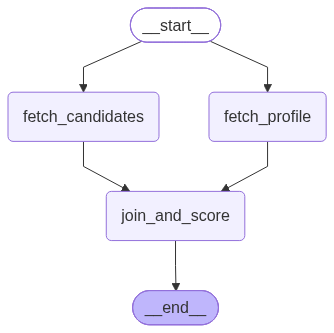

In [47]:

from IPython.display import Image, display

display(
    Image(partial_compiled.get_graph().draw_mermaid_png())
)

In [48]:
initial_state = {
    "raw_query": "waterproof jacket for an October coastal wedding",
    "customer_id": "CUST-001",
    "intent": {
        "raw_query": "waterproof jacket for an October coastal wedding",
        "category": "Outerwear", "occasion": "Wedding", "weather_attribute": "waterproof",
        "material": None, "size": None, "color": None, "max_price": None,
        "keywords": ["coastal", "october"],
    },
    "errors": [],
}

result = partial_compiled.invoke(initial_state)
print(f"{len(result['filtered_skus'])} final SKUs, customer={result['customer_profile']['name']}")
for sku in result["filtered_skus"][:3]:
    print(f"  {sku['sku_id']} | {sku['name']} | score={sku['_composite_score']:.2f}")
print("\nerrors:", result["errors"])

7 final SKUs, customer=Allison Hill
  SKU-1293-30 | Coastal Shorts | score=13.65
  SKU-1126-S | Coastal Trench Coat | score=11.68
  SKU-1781-S | Coastal Trench Coat | score=11.58

errors: []


Same result we saw testing these nodes by hand after Stage 3 — Coastal
Shorts on top for this customer, because Alpine Parka's only size (L)
doesn't fit them. Good: the graph didn't change the *logic*, it just gave
it a real execution/scheduling model. That's the point of using LangGraph
here rather than just calling functions in sequence — 2A and 2B actually
ran concurrently, not because we wrote code to make them concurrent, but
because the graph structure said they could.

## 4. Conditional routing — what happens on zero results?

We already know from the Stage 3 notebook that `filtered_skus` can
legitimately come back empty. Right now our graph doesn't care — it'd feed
an empty list straight into synthesis. Let's build a router and see both
paths for real.

First, we need an actual empty-result case to test against. Mining the real
20-candidate pool for one earlier turned out to be surprisingly hard —
`Accessories` items are never size-filtered, so they kept sneaking in and
keeping the result non-empty even when every shoe/top/bottom candidate got
filtered out. So: for *this* test only, we hand-restrict the candidate list
to two real Footwear products with narrow size availability, to deliberately
and honestly construct the edge case rather than hope to stumble on it.

In [49]:
footwear_only_candidates = [
    {"product_id": "PRD-1199", "name": "Horizon Chelsea Boot", "description": "d",
     "category": "Footwear", "material": "Leather", "occasion": "Formal", "_relevance_score": 5.0},
    {"product_id": "PRD-1369", "name": "Heritage Sandal", "description": "d",
     "category": "Footwear", "material": "Leather", "occasion": "Formal", "_relevance_score": 4.0},
]

shoe_intent = {
    "raw_query": "formal leather oxford shoes",
    "category": "Footwear", "occasion": "Formal", "weather_attribute": None,
    "material": "Leather", "size": None, "color": None, "max_price": None,
    "keywords": ["formal", "leather"],
}

customers = load_customers()
# CUST-002 wears a size 11 shoe; both candidates above are only in stock in 6 and 9.
mismatched_customer = customers["CUST-002"]
print(mismatched_customer["name"], mismatched_customer["size_profile"])

empty_state = {
    "raw_query": shoe_intent["raw_query"],
    "customer_id": "CUST-002",
    "intent": shoe_intent,
    "candidate_products": footwear_only_candidates,
    "customer_profile": mismatched_customer,
    "errors": [],
}

empty_result = join_and_score_node(empty_state)
print("filtered_skus:", empty_result["filtered_skus"])

Noah Rhodes {'tops': 'M', 'bottoms': '28', 'shoes': '11'}
filtered_skus: []


Confirmed empty, on purpose. Now let's write a router function and see
LangGraph actually take the other branch.

In [50]:
def route_after_scoring(state):
    """Router: which node should run after join_and_score?
    Returns the NAME of the next node — LangGraph looks this up in the
    conditional edge mapping below.
    """
    if state.get("filtered_skus"):
        return "has_results"
    return "no_results"

def stub_synthesis(state):
    return {"final_response": f"Here are {len(state['filtered_skus'])} results for you."}

def stub_no_results(state):
    return {"final_response": "We couldn't find anything matching in your size right now — try a different size or check back soon."}

routing_graph = StateGraph(GraphState)
routing_graph.add_node("join_and_score", join_and_score_node)
routing_graph.add_node("synthesis", stub_synthesis)
routing_graph.add_node("no_results", stub_no_results)

routing_graph.add_edge(START, "join_and_score")
routing_graph.add_conditional_edges(
    "join_and_score",
    route_after_scoring,
    {"has_results": "synthesis", "no_results": "no_results"},
)
routing_graph.add_edge("synthesis", END)
routing_graph.add_edge("no_results", END)

routing_compiled = routing_graph.compile()

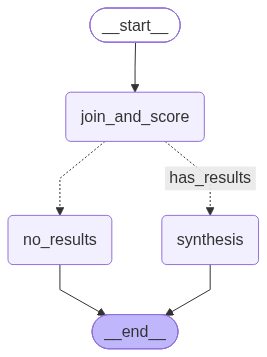

In [51]:

from IPython.display import Image, display

display(
    Image(routing_compiled.get_graph().draw_mermaid_png())
)

In [70]:
# Path A: the empty case from above
out_empty = routing_compiled.invoke(empty_state)
print("EMPTY CASE ->", out_empty["final_response"])

# Path B: a normal, non-empty case (reuse the Stage 3 wedding-jacket example)
non_empty_state = dict(initial_state)  # from section 3
non_empty_state["candidate_products"] = fetch_candidates_node(initial_state)["candidate_products"]
non_empty_state["customer_profile"] = fetch_customer_profile_node(initial_state)["customer_profile"]
out_normal = routing_compiled.invoke(non_empty_state)
print("NORMAL CASE ->", out_normal["final_response"])

EMPTY CASE -> We couldn't find anything matching in your size right now — try a different size or check back soon.
NORMAL CASE -> Here are 7 results for you.


In [72]:
out_normal["filtered_skus"]

[{'product_id': 'PRD-1430',
  'name': 'Coastal Shorts',
  'description': 'Designed for those who want on-trend looks without sacrificing performance, this Wool Blend shorts is waterproof and lightweight from morning commutes to weekend adventures. Reviewers consistently praise how long-lasting the construction feels, thanks to double-stitched seams. It also features eco-friendly recycled materials for added versatility.',
  'category': 'Bottoms',
  'material': 'Wool Blend',
  'occasion': 'Wedding',
  '_relevance_score': 9.854904797639756,
  'sku_id': 'SKU-1293-30',
  'size': '30',
  'stock_count': 29,
  'base_price': 70.33,
  'discount_percentage': 0.4,
  '_category_bonus': 3.0,
  '_personalization_bonus': 0.0,
  '_discount_bonus': 0.8,
  '_composite_score': 13.654904797639757},
 {'product_id': 'PRD-1426',
  'name': 'Coastal Trench Coat',
  'description': "A wardrobe staple, this trench coat pairs modern styling with a flexible feel you'll want to wear all day. Made from Wool, it's eng

Both branches fire correctly, driven entirely by real data — the router
isn't guessing, it's checking the actual `filtered_skus` list. This is the
one piece of real branching logic Stage 4 needs; everything else in the
pipeline so far has been a straight line or a fan-out/fan-in.

## 5. Designing the synthesis prompt

Now the real "has_results" node — not the stub. This one needs an LLM: take
the top few `filtered_skus`, the customer's profile (if any), and the
original query, and write an actual customer-facing recommendation.

Let's draft the prompt and, like Stage 1, prove the mechanics offline with
a fake client before touching the real API.

In [68]:
SYNTHESIS_SYSTEM_PROMPT = """
You are a friendly, knowledgeable retail shopping assistant. You'll be given
a customer's original search query, a short ranked list of matching products
(with size, price, and discount info), and optionally the customer's name and
style preferences.

Write a brief, warm, natural-language response (2-4 sentences) that:
- Directly addresses what they searched for
- Highlights the top 1-3 results by name, mentioning price and any discount
- If a size/stock note applies (e.g. their usual pick wasn't available in
  their size), mention it naturally, don't apologize excessively
- Do NOT invent products, prices, or details not present in the provided list
- If the provided list is empty, say so honestly and suggest trying a
  different size or checking back later - don't pretend there are results
"""


def build_synthesis_user_prompt(raw_query, filtered_skus, customer_profile):
    customer_line = (
        f"Customer: {customer_profile['name']}, style preferences: {customer_profile['style_preferences']}"
        if customer_profile else "Customer: guest (no profile)"
    )
    skus_summary = [
        {
            "name": s["name"], "size": s["size"], "price": s["base_price"],
            "discount_percentage": s["discount_percentage"],
        }
        for s in filtered_skus[:5]
    ]
    return (
        f'Original query: "{raw_query}"\n'
        f"{customer_line}\n"
        f"Top matching results (JSON): {json.dumps(skus_summary)}\n\n"
        "Write the customer-facing response."
    )


print(build_synthesis_user_prompt(
    "waterproof jacket for an October coastal wedding",
    out_normal.get("filtered_skus", non_empty_state.get("filtered_skus", [])) or [],
    non_empty_state["customer_profile"],
))

Original query: "waterproof jacket for an October coastal wedding"
Customer: Allison Hill, style preferences: ['classic', 'athleisure', 'durable', 'vintage']
Top matching results (JSON): [{"name": "Coastal Shorts", "size": "30", "price": 70.33, "discount_percentage": 0.4}, {"name": "Coastal Trench Coat", "size": "S", "price": 156.59, "discount_percentage": 0.15}, {"name": "Coastal Trench Coat", "size": "S", "price": 85.68, "discount_percentage": 0.1}, {"name": "Coastal Hoodie", "size": "S", "price": 228.07, "discount_percentage": 0.1}, {"name": "Cascade Trail Runner", "size": "7", "price": 161.69, "discount_percentage": 0.25}]

Write the customer-facing response.


Notice `filtered_skus` isn't actually in `out_normal` — the stub synthesis
node from section 4 didn't pass it through into the final state on purpose
(it only returned `final_response`). That's worth remembering for the real
node: it needs to read `state["filtered_skus"]` directly, not rely on a
previous stub's behavior. Let's rebuild the prompt input directly from
`non_empty_state` instead, which does have it.

In [55]:
sample_prompt = build_synthesis_user_prompt(
    non_empty_state["raw_query"],
    non_empty_state.get("filtered_skus") or join_and_score_node(non_empty_state)["filtered_skus"],
    non_empty_state["customer_profile"],
)
print(sample_prompt)

Original query: "waterproof jacket for an October coastal wedding"
Customer: Allison Hill, style preferences: ['classic', 'athleisure', 'durable', 'vintage']
Top matching results (JSON): [{"name": "Coastal Shorts", "size": "30", "price": 70.33, "discount_percentage": 0.4}, {"name": "Coastal Trench Coat", "size": "S", "price": 156.59, "discount_percentage": 0.15}, {"name": "Coastal Trench Coat", "size": "S", "price": 85.68, "discount_percentage": 0.1}, {"name": "Coastal Hoodie", "size": "S", "price": 228.07, "discount_percentage": 0.1}, {"name": "Cascade Trail Runner", "size": "7", "price": 161.69, "discount_percentage": 0.25}]

Write the customer-facing response.


### Offline test with a fake client

Same fake-Claude pattern as the Stage 1 notebook — no API key needed to see
the mechanics work.

In [56]:
from types import SimpleNamespace

def make_text_response(text):
    block = SimpleNamespace(type="text", text=text)
    return SimpleNamespace(content=[block])

class FakeMessages:
    def __init__(self, responses):
        self._responses = list(responses)
    def create(self, **kwargs):
        return self._responses.pop(0)

class FakeAnthropicClient:
    def __init__(self, responses):
        self.messages = FakeMessages(responses)

fake_synthesis_client = FakeAnthropicClient([
    make_text_response(
        "For your October coastal wedding, the Coastal Shorts ($129.99, 10% off) "
        "are a great pick and in stock in your size. We didn't have the Alpine "
        "Parka in a small, but this is a strong, weather-ready alternative."
    )
])

response = fake_synthesis_client.messages.create()
text_block = next(b for b in response.content if b.type == "text")
print(text_block.text)

For your October coastal wedding, the Coastal Shorts ($129.99, 10% off) are a great pick and in stock in your size. We didn't have the Alpine Parka in a small, but this is a strong, weather-ready alternative.


### Real API call (optional — needs `GROQ_API_KEY`)

In [57]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads .env if present

HAVE_API_KEY = bool(os.getenv("GROQ_API_KEY"))
print(f"GROQ_API_KEY set: {HAVE_API_KEY}")

if HAVE_API_KEY:
    from langchain_groq import ChatGroq
    from langchain_core.messages import HumanMessage, SystemMessage

    llm = ChatGroq(
        model=os.getenv("SEARCH_AGENT_LLM_MODEL", "llama-3.3-70b-versatile"),
        temperature=float(os.getenv("SEARCH_AGENT_TEMPERATURE", "0.7")),
        api_key=os.getenv("GROQ_API_KEY"),
    )

    response = llm.invoke([
        SystemMessage(content=SYNTHESIS_SYSTEM_PROMPT),
        HumanMessage(content=sample_prompt),
    ])
    print(response.content)
else:
    print("Skipping real API call, no GROQ_API_KEY found in the environment.")

GROQ_API_KEY set: True
Hi Allison, I found some great options for a waterproof jacket for the October coastal wedding. The Coastal Trench Coat in size S is a great choice, with one option priced at $156.59 with a 15% discount, and another at $85.68 with a 10% discount. If you're looking for something a bit different, the Cascade Trail Runner in size 7 is also waterproof and on sale with a 25% discount, priced at $161.69.


## 6. The full graph, end to end

Stage 1 needs a real API key (it's the only LLM-backed node besides
synthesis). If one is present, we wire in the real
`extract_intent_node`; otherwise we substitute a clearly-labeled stub so the
rest of the graph can still be exercised end to end.

In [58]:
def real_synthesis_node(state):
    """The actual node — a simplified inline version of what becomes
    `nodes/stage4_synthesis.py`."""
    prompt = build_synthesis_user_prompt(
        state["raw_query"], state.get("filtered_skus") or [], state.get("customer_profile")
    )
    if HAVE_API_KEY:
        from langchain_groq import ChatGroq
        from langchain_core.messages import HumanMessage, SystemMessage

        llm = ChatGroq(
            model=os.getenv("SEARCH_AGENT_LLM_MODEL", "llama-3.3-70b-versatile"),
            temperature=float(os.getenv("SEARCH_AGENT_TEMPERATURE", "0.7")),
            api_key=os.getenv("GROQ_API_KEY"),
        )
        response = llm.invoke([
            SystemMessage(content=SYNTHESIS_SYSTEM_PROMPT),
            HumanMessage(content=prompt),
        ])
        text = response.content
    else:
        # offline stand-in so the full graph can still run without a key
        text = f"[offline demo] Found {len(state.get('filtered_skus') or [])} result(s) for: {state['raw_query']!r}"
    return {"final_response": text}


def no_results_node(state):
    return {
        "final_response": (
            "We couldn't find anything matching in your size right now — "
            "try a different size or check back soon."
        )
    }


if HAVE_API_KEY:
    from search_agent.nodes.stage1_intent_extraction import extract_intent_node
    stage1_node = extract_intent_node
    print("Using the REAL Stage 1 intent extraction node")
else:
    def stage1_node(state):
        # stub — stands in for extract_intent_node when no API key is available
        return {
            "intent": {
                "raw_query": state["raw_query"], "category": "Outerwear", "occasion": "Wedding",
                "weather_attribute": "waterproof", "material": None, "size": None, "color": None,
                "max_price": None, "keywords": ["coastal", "october"],
            }
        }
    print("No API key — using a STUB Stage 1 node (fixed intent, for graph-wiring purposes only)")

Using the REAL Stage 1 intent extraction node


In [59]:
full_graph = StateGraph(GraphState)
full_graph.add_node("extract_intent", stage1_node)
full_graph.add_node("fetch_candidates", fetch_candidates_node)
full_graph.add_node("fetch_profile", fetch_customer_profile_node)
full_graph.add_node("join_and_score", join_and_score_node)
full_graph.add_node("synthesis", real_synthesis_node)
full_graph.add_node("no_results", no_results_node)

full_graph.add_edge(START, "extract_intent")
full_graph.add_edge("extract_intent", "fetch_candidates")
full_graph.add_edge("extract_intent", "fetch_profile")
full_graph.add_edge("fetch_candidates", "join_and_score")
full_graph.add_edge("fetch_profile", "join_and_score")
full_graph.add_conditional_edges(
    "join_and_score",
    route_after_scoring,
    {"has_results": "synthesis", "no_results": "no_results"},
)
full_graph.add_edge("synthesis", END)
full_graph.add_edge("no_results", END)

full_compiled = full_graph.compile()
print("Graph compiled")

Graph compiled


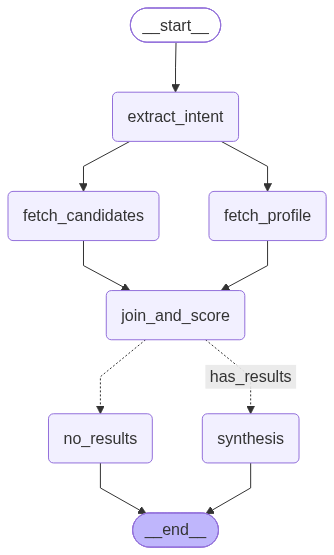

In [60]:

from IPython.display import Image, display

display(
    Image(full_compiled.get_graph().draw_mermaid_png())
)

In [61]:
final_result = full_compiled.invoke({
    "raw_query": "night wear breathable soft during summer with loose size and light color I need 5 pieces ",
    "customer_id": "CUST-004",
    "errors": [],
})

print("intent:", json.dumps(final_result.get("intent"), indent=2))
print()
print("final_response:", final_result["final_response"])
print()
print("errors:", final_result["errors"])

intent: {
  "raw_query": "night wear breathable soft during summer with loose size and light color I need 5 pieces",
  "category": "Tops",
  "occasion": "Casual",
  "weather_attribute": "quick-drying",
  "material": null,
  "size": "loose",
  "color": "light",
  "max_price": null,
  "keywords": [
    "breathable",
    "soft",
    "loose",
    "light color"
  ]
}

final_response: Hi Daniel, I've found some great breathable night wear options for you. The Metro Hoodie and Coastal Polo are both available in XXL and have significant discounts, with prices starting at $85.07 and $100.40 respectively. The Summit T-Shirt is another lightweight option, priced at $49.44 with a 25% discount, which should fit your casual and minimalist style preferences.

errors: []


End to end: raw query in, final customer-facing response out, with Stage
2A/2B genuinely running in parallel and Stage 3's conditional routing
genuinely branching based on real data — all through one compiled graph.

## 7. What we now know, going into the modules

1. **Every existing node already fit the graph unchanged** — `(state) ->
   partial dict` was the right contract to settle on back in Stage 1,
   confirmed here rather than assumed.
2. **Fan-out/fan-in needs nothing special beyond edges** — `add_edge(X, A)`
   + `add_edge(X, B)` is a fan-out, `add_edge(A, Y)` + `add_edge(B, Y)` is a
   fan-in. The `errors` reducer (`operator.add`) is what keeps parallel
   writes from clobbering each other — proven, not assumed, in section 2.
3. **Conditional routing is one function + one `add_conditional_edges`
   call.** `route_after_scoring` just checks `state["filtered_skus"]` —
   simple, and it needs to be, since state is the only thing routing logic
   should ever depend on.
4. **The empty-results path is not an edge case to bolt on later** — it's a
   first-class branch with its own node (`no_results`) and its own, honest
   response text. Finding a genuine empty case took deliberately
   constructing one (see section 4) — worth remembering that natural query
   diversity may make this rarer in practice than it seems, but it *will*
   happen with narrow candidate pools or unusual customer sizes.
5. **Stage 1 is the one node that can't run in this sandbox without a key**
   — everything else (2A, 2B, 3, and the routing) is fully real. The stub
   used above is clearly separated from the real node and only stands in
   for graph-wiring demonstration.
6. **The synthesis prompt is deliberately constrained**: told explicitly not
   to invent products/prices, and told what to say when the list is empty,
   rather than relying on it to "figure out" the right tone for a null
   result.

**Open questions for you before I write the modules:**
- Should `errors` accumulated earlier in the graph (e.g. a Stage 2A
  failure) get surfaced to the customer somehow (e.g. "results may be
  incomplete"), or stay purely internal/logging?
- Any interest in LangGraph's checkpointing/memory (for multi-turn
  conversations) for this MVP, or is single-shot invoke() enough for now?
- Where should the `route_after_scoring` function and its string constants
  (`"has_results"` / `"no_results"`) live — inside `graph/builder.py`
  itself, or as a separate `graph/routing.py`?

In [62]:
from collections import Counter
import math

docs = [
    "waterproof jacket lightweight",
    "leather jacket",
    "formal blazer wedding"
]

tokenized = [doc.split() for doc in docs]
tokenized

[['waterproof', 'jacket', 'lightweight'],
 ['leather', 'jacket'],
 ['formal', 'blazer', 'wedding']]

In [63]:
# Document Frequency
df = Counter()
for tokens in tokenized:
    df.update(set(tokens))


In [64]:
df

Counter({'jacket': 2,
         'lightweight': 1,
         'waterproof': 1,
         'leather': 1,
         'blazer': 1,
         'formal': 1,
         'wedding': 1})

In [65]:
# IDF
N = len(tokenized)
idf = {word: math.log(N/(1+freq))+1 for word, freq in df.items()}

In [66]:
idf

{'jacket': 1.0,
 'lightweight': 1.4054651081081644,
 'waterproof': 1.4054651081081644,
 'leather': 1.4054651081081644,
 'blazer': 1.4054651081081644,
 'formal': 1.4054651081081644,
 'wedding': 1.4054651081081644}

In [67]:
# Query
query = ["waterproof", "jacket"]

print("Scores")
for doc in tokenized:
    tf = Counter(doc)
    score = sum(tf[word] * idf.get(word, 0) for word in query)
    print(doc, "->", score)

Scores
['waterproof', 'jacket', 'lightweight'] -> 2.4054651081081646
['leather', 'jacket'] -> 1.0
['formal', 'blazer', 'wedding'] -> 0.0
